# Etapa 1 — Tendência Temporal de Termos

**Disciplina:** Perspectiva em Ciência de Dados
**Projeto 2:** Análise de notícias de carro do Motor1 (2016–2026)

---

## Pergunta-guia do projeto

> **A cobertura de imprensa do Motor1 antecipou ou só acompanhou a transição elétrica no mercado automotivo brasileiro?**

Todas as etapas do projeto (esta e as próximas) vão gerar evidências para responder essa pergunta central, em vez de serem análises soltas.

## Objetivo desta etapa

Medir, ano a ano, **que proporção das notícias do Motor1 menciona** um conjunto de termos relevantes para a transição do mercado automotivo (elétrico, híbrido, direção autônoma, SUV, diesel, flex) e verificar estatisticamente se existe uma **tendência de crescimento ou queda** em cada um deles.

Essa proporção normalizada pelo volume de notícias do período é o que depois vamos comparar com dados reais de venda (Etapa 6, dados da ANFAVEA).

---
## 1. Importações e Configurações

- `pandas`: carregar e agregar os dados
- `re`: expressões regulares para localizar os termos no texto
- `unidecode`: remover acentos, para não perder menções por causa de "elétrico" vs "eletrico"
- `matplotlib`: gráficos da evolução temporal
- `pymannkendall`: teste estatístico de tendência monotônica (Mann-Kendall)

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
import pymannkendall as mk

# ── Caminhos de arquivo ───────────────────────────────────────────────────────
# Este notebook está em projeto/notebooks/tendencia_termos/
# e a pasta de dados está em      projeto/dados/
# Seguindo a mesma convenção do notebook de webscraping: sobe dois níveis.
_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "..", "..", "dados"))

ARQUIVO_NOTICIAS = os.path.join(DATA_DIR, "noticias_motor1_2016_2026.csv")
ARQUIVO_SAIDA    = os.path.join(DATA_DIR, "tendencia_termos_por_ano.csv")

print(f"Data dir : {DATA_DIR}")
print(f"Existe?  : {os.path.isdir(DATA_DIR)}")

Data dir : /home/claude/work/projeto/dados
Existe?  : True


---
## 2. Carregando os dados

Usamos o dataset final gerado na etapa de web scraping (`noticias_motor1_2016_2026.csv`).

In [2]:
df = pd.read_csv(ARQUIVO_NOTICIAS, parse_dates=["data_publicacao"])

print(f"Total de notícias: {len(df):,}")
print(f"Período coberto  : {df['data_publicacao'].min().date()} → {df['data_publicacao'].max().date()}")

df[["data_publicacao", "titulo", "categoria"]].head()

Total de notícias: 26,917
Período coberto  : 2016-01-01 → 2026-06-23


,data_publicacao,titulo,categoria
0,2016-01-01 08:01:33,Faróis a laser: você está disposto a pagar (ca...,Geral
1,2016-01-04 15:18:00,Inusitada: BMW R1200 GS ganha versão com traçã...,Motos
2,2016-01-05 10:00:00,FCA apresenta central Uconnect com Android Aut...,Tecnologia
3,2016-01-06 13:45:24,CES 2016: BMW apresenta capacete com head-up d...,Motos
4,2016-01-09 08:20:25,Veja a lista dos 10 carros mais vendidos nos E...,Geral


---
## 3. Normalização do texto

Antes de procurar os termos, normalizamos o texto:

- juntamos `titulo` + `subtitulo` + `texto_completo` (o termo pode aparecer só no título)
- colocamos tudo em minúsculas
- removemos acentos com `unidecode` (assim "elétrico" e "eletrico" viram a mesma coisa)
- removemos pontuação, mantendo apenas letras, números e espaços

Isso evita perder menções só porque a escrita variou (acento, maiúscula, pontuação colada na palavra).

In [3]:
import re


def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return texto


df["texto_limpo"] = (
    df["titulo"].fillna("") + " " +
    df["subtitulo"].fillna("") + " " +
    df["texto_completo"].fillna("")
).apply(limpar_texto)

print(df["texto_limpo"].iloc[0][:300])

farois a laser  voce esta disposto a pagar  caro  pela tecnologia  farois a laser  voce esta disposto a pagar  caro  pela tecnologia  top videos  queremos a sua opiniao  o que voce gostaria de ver no motor1 com    equipe do motor1 com


---
## 4. Por que não basta procurar a palavra "elétrico"?

Antes de definir os termos, vale a pena checar como eles aparecem de verdade no texto. Uma busca ingênua por `"eletric"` parece razoável, mas em notícias de carro essa raiz aparece o tempo todo em **acessórios do veículo**, sem nenhuma relação com o carro ser elétrico:

> *"vidros e travas **eletricas**"*, *"retrovisores com ajuste **eletrico**"*, *"porta-malas **eletrico**"*, *"direção **eletrica**"*

O mesmo acontece com `"autonom"`: a maior parte das ocorrências é da palavra **"autonomia"**, que em notícia de carro quase sempre significa **alcance do tanque/bateria** (`"autonomia de 300 km"`), não direção autônoma.

Vamos confirmar isso contando quantas notícias "batem" com a busca ingênua antes de refinar os termos.

In [4]:
n_ingenuo_eletrico = df["texto_limpo"].str.contains("eletric").sum()
n_ingenuo_autonomo = df["texto_limpo"].str.contains("autonom").sum()

print(f"Notícias com 'eletric' (busca ingênua): {n_ingenuo_eletrico:,}")
print(f"Notícias com 'autonom' (busca ingênua): {n_ingenuo_autonomo:,}")

# Exemplo de falso positivo: "eletrico" em acessório, não em motorização
exemplo = df[df["texto_limpo"].str.contains("ajuste eletrico|vidros eletric|trava eletrica")]["texto_limpo"].iloc[0]
pos = exemplo.find("eletric")
print()
print("Exemplo de falso positivo (acessório, não motorização):")
print("..." + exemplo[max(0, pos - 40): pos + 20] + "...")

Notícias com 'eletric' (busca ingênua): 9,450
Notícias com 'autonom' (busca ingênua): 3,198



Exemplo de falso positivo (acessório, não motorização):
...os pneus  banco do motorista com ajuste eletrico   kit techn...


---
## 5. Definindo os termos de interesse

Para reduzir os falsos positivos identificados acima, usamos:

- **`eletrico`**: em vez da raiz solta, procuramos combinações específicas de motorização elétrica (`"carro eletrico"`, `"motor eletrico"`, `"eletrificacao"`, `"bateria eletrica"`, etc.), evitando acessórios elétricos comuns em qualquer carro.
- **`autonomo`**: usamos `autonom[oa]s?\b`, que casa com "autônomo/autônoma/autônomos/autônomas" mas **não** casa com "autonomia" (a palavra termina em "ia", não em "o"/"a" seguido de fim de palavra).
- Os demais termos (`hibrido`, `suv`, `diesel`, `flex`) não mostraram esse problema na inspeção manual, então usamos a raiz da palavra com `\b` para não pegar palavras coladas (ex.: `\bflex` evita casar com "reflexo").

In [5]:
TERMOS = {
    "eletrico": (
        r"carro eletric|carros eletric|veiculo eletric|veiculos eletric|"
        r"motor eletric|motores eletric|100% eletric|totalmente eletric|"
        r"puramente eletric|eletrificaca|eletrificad|autonomia eletrica|"
        r"bateria eletric|carro a bateria|sedan eletric|suv eletric|"
        r"picape eletric|hatch eletric"
    ),
    "hibrido": r"hibrid",
    "autonomo": r"autonom[oa]s?\b",
    "suv": r"\bsuv",
    "diesel": r"\bdiesel",
    "flex": r"\bflex\b",
}

for nome, padrao in TERMOS.items():
    df[f"menciona_{nome}"] = df["texto_limpo"].str.contains(padrao, regex=True)

n_refinado_eletrico = df["menciona_eletrico"].sum()
n_refinado_autonomo = df["menciona_autonomo"].sum()

print(f"Notícias com 'eletrico' (refinado): {n_refinado_eletrico:,} "
      f"(era {n_ingenuo_eletrico:,} na busca ingênua)")
print(f"Notícias com 'autonomo' (refinado): {n_refinado_autonomo:,} "
      f"(era {n_ingenuo_autonomo:,} na busca ingênua)")

Notícias com 'eletrico' (refinado): 6,109 (era 9,450 na busca ingênua)
Notícias com 'autonomo' (refinado): 1,241 (era 3,198 na busca ingênua)


---
## 6. Contando menções por ano, normalizado pelo volume de notícias

Contar o número absoluto de menções não é suficiente: se o Motor1 publicou mais notícias em um ano, é natural que apareçam mais menções de qualquer termo. Por isso calculamos a **proporção de notícias do ano que mencionam o termo**, e não a contagem bruta.

In [6]:
df["ano"] = df["data_publicacao"].dt.year

colunas_menciona = [f"menciona_{nome}" for nome in TERMOS]

agg_ano = df.groupby("ano").agg(
    total_noticias=("id_noticia", "count"),
    **{f"qtd_{nome}": (f"menciona_{nome}", "sum") for nome in TERMOS},
)

for nome in TERMOS:
    agg_ano[f"prop_{nome}"] = (agg_ano[f"qtd_{nome}"] / agg_ano["total_noticias"] * 100).round(2)

colunas_prop = [f"prop_{nome}" for nome in TERMOS]
agg_ano[["total_noticias"] + colunas_prop]

,total_noticias,prop_eletrico,prop_hibrido,prop_autonomo,prop_suv,prop_diesel,prop_flex
ano,,,,,,,
2016,705,3.55,4.96,4.11,13.05,6.95,3.69
2017,3455,7.90,9.15,4.49,30.19,8.25,4.23
2018,2864,13.06,12.12,5.06,39.49,8.87,5.55
2019,2570,20.19,18.37,4.44,40.51,7.47,5.21
2020,2341,12.17,19.91,2.78,41.86,7.13,6.71
2021,2677,16.96,19.54,3.47,44.12,6.84,7.73
2022,2941,28.26,23.53,3.94,43.62,7.48,7.24
2023,2813,29.04,27.34,5.15,39.71,8.57,9.28
2024,2717,33.79,30.77,3.90,40.41,6.81,9.83


---
## 7. Teste de tendência (Mann-Kendall)

O gráfico da proporção ao longo dos anos pode até "parecer" que está subindo, mas isso é olhômetro. O **teste de Mann-Kendall** verifica estatisticamente se existe uma tendência monotônica (sempre subindo ou sempre descendo, sem exigir que seja uma reta) na série e retorna:

- `trend`: `"increasing"`, `"decreasing"` ou `"no trend"`
- `p`: p-valor do teste (convencionalmente, p < 0,05 indica tendência estatisticamente significativa)
- `Tau`: força/direção da tendência (-1 a 1)

Usamos apenas os anos **completos** (2016 a 2025), já que 2026 está em andamento e o volume de notícias do ano ainda não é comparável aos anteriores.

In [7]:
serie_completa = agg_ano.loc[2016:2025]

resultados_mk = []
for nome in TERMOS:
    r = mk.original_test(serie_completa[f"prop_{nome}"])
    resultados_mk.append({
        "termo": nome,
        "tendencia": r.trend,
        "p_valor": round(r.p, 4),
        "tau": round(r.Tau, 3),
    })

df_mk = pd.DataFrame(resultados_mk).sort_values("p_valor")
df_mk

,termo,tendencia,p_valor,tau
1,hibrido,increasing,0.0002,0.956
5,flex,increasing,0.0003,0.911
0,eletrico,increasing,0.0007,0.867
3,suv,increasing,0.0200,0.600
4,diesel,no trend,0.4743,-0.200
2,autonomo,no trend,0.7205,0.111


---
## 8. Visualizando a evolução dos termos

Por fim, plotamos a proporção de notícias que mencionam cada termo, ano a ano (incluindo 2026, marcado como parcial no eixo).

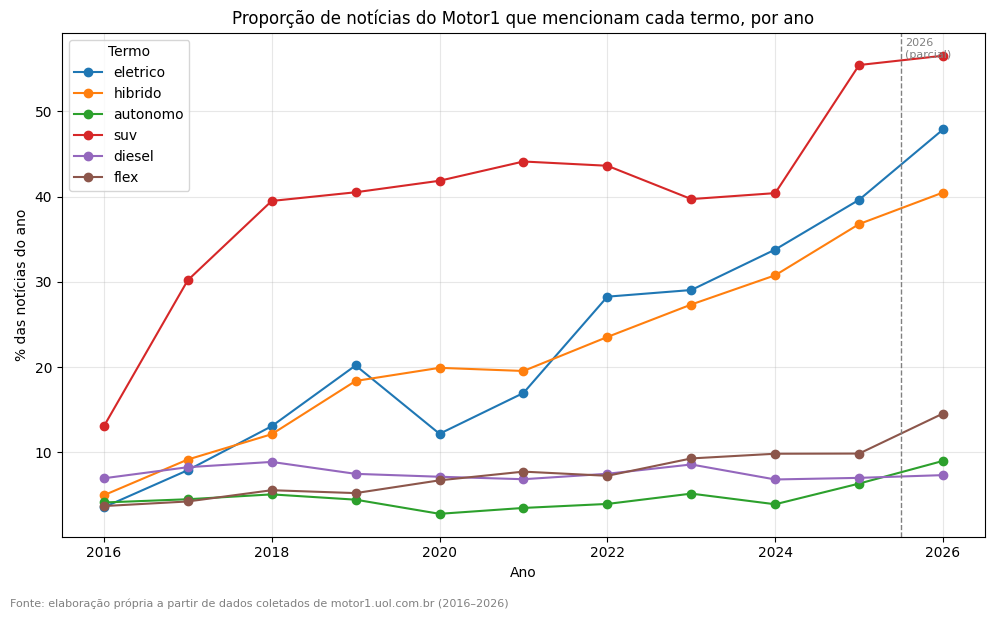

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for nome in TERMOS:
    ax.plot(agg_ano.index, agg_ano[f"prop_{nome}"], marker="o", label=nome)

ax.axvline(2025.5, color="gray", linestyle="--", linewidth=1)
ax.text(2025.55, ax.get_ylim()[1] * 0.95, "2026\n(parcial)", fontsize=8, color="gray")

ax.set_title("Proporção de notícias do Motor1 que mencionam cada termo, por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("% das notícias do ano")
ax.legend(title="Termo")
ax.grid(alpha=0.3)
fig.text(0.01, -0.02, "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (2016–2026)",
          fontsize=8, color="gray")

plt.tight_layout()
plt.show()

---
## 9. Salvando os resultados

Salvamos a tabela agregada por ano para reaproveitar nas próximas etapas (ex.: cruzar com clusters da Etapa 2, ou com dados de venda da ANFAVEA na Etapa 6).

In [9]:
agg_ano.to_csv(ARQUIVO_SAIDA)
print(f"Tabela salva em: {ARQUIVO_SAIDA}")

Tabela salva em: /home/claude/work/projeto/dados/tendencia_termos_por_ano.csv


---
## Conclusão da Etapa 1

- **Elétrico** e **híbrido** são os termos com crescimento mais forte e mais consistente: a proporção de notícias que mencionam motorização elétrica saiu de cerca de 3% em 2016 para mais de 40% em 2025, com tendência estatisticamente significativa pelo teste de Mann-Kendall (p < 0,01 para os dois termos).
- **SUV** também cresce de forma significativa, mas de forma mais moderada — consistente com a tendência (já bem documentada no mercado) de "suvização" da linha de produtos.
- **Direção autônoma** (`autonomo`, já filtrado de "autonomia" de alcance) **não** apresenta tendência estatisticamente significativa no período — ao contrário do que a repercussão do tema sugere, o Motor1 não aumentou consistentemente sua cobertura sobre carros autônomos.
- **Diesel** não mostra tendência clara (nem de queda, como seria de se esperar com a eletrificação, nem de alta).

Isso já começa a dar pistas para a pergunta-guia do projeto: a cobertura do Motor1 acompanha de perto a eletrificação (crescimento forte e estatisticamente consistente), mas não necessariamente **antecipa** ela — isso só vamos conseguir responder de verdade na Etapa 6, comparando esse crescimento de cobertura com o ano em que as vendas de elétricos/híbridos de fato decolaram (dados da ANFAVEA).

## Próximos passos

| Etapa | Notebook |
|---|---|
| Clustering / tópicos com TF-IDF + t-SNE | `tsne.ipynb` |
| Cruzar termo/tópico × marca + sentimento | `cruzamento_marca.ipynb` |
| Classificação supervisionada | `modeling.ipynb` |